In [26]:
from CRNs import *
import numpy as np
import argparse
import time
import copy
import pickle


seed = 40
np.random.seed(seed)
random.seed(seed)

#### Random network 
# n_species = 10
# n_complexes = 11
# n_reactions = 10
# force_reverse = True
# L = np.array([[2, 1, 1, 0, 0, 0, 0, 0, 0, 0],
#               [0, 0, 0, 2, 1, 1, 0, 0, 0, 0],
#               [0, 0, 0, 0, 0, 0, 1, 1, 1, 1]])

# n_cons = len(L)
# n_lcs = n_complexes - n_species + n_cons
# subset_group_ind = None
# seed = None
# r_n_base = None

# input_dims = [0]
# default_l0 = np.ones(n_species)
# sc_grad_dims = [[6,7,8,9],[0]]

#### Random dimerization network 
# NL = 5
# prob = 1
# species_names, reaction_strings, L = generate_random_dimerization_network(NL, prob, include_reverse=False)

## Signaling network 
# NR = 1
# NS = 4
# p_f = 0.75
# p_r = 0.0
# species_names, reaction_strings, L, adjacency_matrix, input_substrates_list = generate_dag_signaling_network(NR, NS, p_f, p_r, include_reverse=False, include_uncatalyzed=True)
# G = get_digraph_from_adjacency_matrix(adjacency_matrix, input_substrates_list, NR, NS)
# target_node = 'S'+str(NR+NS-2)
# print(len(count_simple_paths(G, 'R0', target_node)))
# target_node_idx = species_names.index(target_node)


NR = 1
n_nodes = 4
NS = 1
prob = 1
extra_reactions = ['D+B -> D+C']
#extra_reactions = []
input_reactions_list = [['R0+A -> R0+B']]
input_substrates_list = ['A']
species_names, reaction_strings, L = generate_random_first_order_network(n_nodes, input_reactions_list, prob, extra_reactions = extra_reactions, include_reverse=False)
target_node = 'D'
target_node_idx = species_names.index(target_node)
adjacency_matrix = np.array([[0,1],[0,0]])

r_n = ReactionNetwork.from_reaction_strings(
    reaction_strings=reaction_strings,
    L=L,
    seed=seed,
    species_names=species_names,
    force_reverse=True
)

n_species = r_n.n_species
n_complexes = r_n.n_complexes
n_reactions = int(r_n.n_reactions / 2)
n_lcs = r_n.n_lcs
n_cons = len(L)
r_n_base = r_n

input_dims = [0]
default_l0 = np.ones(NR+NS)
sc_grad_dims = [[NR+NS-1],[0]]


E_range = 5.0
B_range = 5.0
F_range = 5.0
C0 = 1
beta = 1
l0_range = (1e-3, 1e3)

use_signal_alarms = False

n_graph_samples = 500

lhs_bool = True
if lhs_bool:
    E_lists = [(-E_range, E_range) for _ in range(n_species)]
    B_lists = [(-B_range, B_range) for _ in range(n_reactions)]
    F_lists = [(-F_range, F_range) for _ in range(n_reactions)]
    l0_lists = [(np.log10(l0_range[0]), np.log10(l0_range[1])) for _ in range(n_cons)]
    ranges = E_lists + B_lists + F_lists + l0_lists
    samples = list(latin_hypercube_sampling(ranges, n_graph_samples, seed))


t_span = (0, 10000)
num_points = 100000
int_method = 'LSODA'
r_tol = 1e-12  
a_tol = 1e-12


if seed is not None:
    np.random.seed(seed)
    random.seed(seed)


# Initialize data logger and time profiler
data_logger = NetworkDataLogger()
profiler = TimeProfiler()
profiler.start_total_timer()

sampler = GridSampler(
    input_dims=input_dims,
    default_l0=default_l0,
    sc_grad_dims=sc_grad_dims,
    l0_range=l0_range,
    l0_grid_size=50,
    grid_dim=1,
    timeout_seconds=1,
    profiler=profiler,
    round_decimals=6,
    use_signal_alarms=use_signal_alarms,
    use_contour_integration=True
)

for iter in range(n_graph_samples):

    # Time network generation
    profiler.start_timer("network_generation")
    try:
        if r_n_base is None:
            r_n = ReactionNetwork(  
                n_species, 
                n_complexes, n_reactions, n_lcs, 
                L, seed, force_reverse=force_reverse, subset_group_ind=subset_group_ind, 
                #complexes_per_class=complexes_per_class, reactions_per_class=reactions_per_class
            )
        else:
            r_n = r_n_base
        if lhs_bool:
            sample = samples[iter]
            E_list = sample[:n_species]
            B_list = sample[n_species:n_species+n_reactions]
            F_list = sample[n_species+n_reactions:n_species+n_reactions+n_reactions]
            reac_rates = get_rates_from_exponents(r_n, E_list, B_list, F_list, C0, beta)
            r_n.update_rates(reac_rates)

            default_l0 = 10**np.array(sample[n_species+n_reactions+n_reactions:])
            sampler.default_l0 = default_l0

        else:
            reac_rates = generate_thermodynamic_rates(r_n, C0, beta, E_range, B_range, F_range)
            r_n.update_rates(reac_rates)

            default_l0 = np.exp(np.random.uniform(np.log(l0_range[0]), np.log(l0_range[1]), n_cons))
            sampler.default_l0 = default_l0

        profiler.end_timer("network_generation")
    except Exception as e:
        profiler.end_timer("network_generation")
        print(f"Error creating reaction network: {e}, skipping...")
        continue

    if r_n_base is None or iter == 0:
        # Time conservation group analysis
        profiler.start_timer("conservation_analysis")
        # M_0t1, M_1t0, M_0b1 = count_conservation_group_changes(r_n)
        interaction_matrix = get_interaction_matrix(r_n)
        profiler.end_timer("conservation_analysis")
        
        # Time data storage operations
        profiler.start_timer("data_storage")
        cycles = compute_cycles(r_n)
        profiler.end_timer("data_storage")

        # Time simulator initialization
        profiler.start_timer("simulator_init")
        sim = ReactionNetworkSimulator(r_n)
        profiler.end_timer("simulator_init")
        
        # Time conservation laws solving
        profiler.start_timer("conservation_laws")
        sim.solve_conservation_laws()
        profiler.end_timer("conservation_laws")
        
        # Time symbolic RHS generation
        profiler.start_timer("symbolic_rhs")
        reduced_rhs, remaining_syms, const_syms, rate_syms = sim.get_symbolic_reduced_rhs()
        profiler.end_timer("symbolic_rhs")
        
        # Time derivatives computation
        profiler.start_timer("derivatives")
        # Only compute the derivatives we actually use
        dR_dC, dR_dC_func, dR_dl, dR_dl_func, dR_dk, dR_dk_func, remaining_syms = sim.get_first_order_derivatives()
        # Store the derivative functions that will be reused in adaptive sampling
        precomputed_derivatives = (dR_dC_func, dR_dl_func)

        profiler.end_timer("derivatives")
        
        # Time rates creation
        profiler.start_timer("rates_creation")
        rates = np.array([r_n.reactions[r_idx][2] for r_idx in range(len(r_n.reactions))])
        profiler.end_timer("rates_creation")
        
        # Time flexible RHS creation
        profiler.start_timer("flexible_rhs")
        flexible_reduced_ode_rhs = sim.make_reduced_rhs_with_conservation_flexible()
        profiler.end_timer("flexible_rhs")

    # Use adaptive sampling instead of fixed sampling
    # Note: The adaptive sampler handles its own internal timing with "adaptive_" prefixed timers
    profiler.start_timer("adaptive_sampling")
    sign_conditions, C_full_list, dC_dl_list, l0_list, sample_count, convergence_reached = sampler.sample_sign_conditions(
        sim=sim,
        L=L,
        t_span=t_span,
        num_points=num_points,
        int_method=int_method,
        r_tol=r_tol,
        a_tol=a_tol,
        precomputed_derivatives=precomputed_derivatives
    )
    profiler.end_timer("adaptive_sampling")
    
    # Reset sampler for next network
    sampler.reset()
    
    # Log the network data using the new logger
    profiler.start_timer("data_logging")


    dC_dl_list_sub = [dC_dl[target_node_idx, input_dims[0]] for dC_dl in dC_dl_list]
    C_full_list_sub = [C_full[target_node_idx] for C_full in C_full_list]

    data_logger.log_network(
        r_n=r_n,
        interaction_matrix=interaction_matrix,
        input_substrates_list=input_substrates_list,
        NR=NR,
        NS=NS,
        target_node=target_node,
        cycles=cycles,
        adjacency_matrix=adjacency_matrix,
        # C_full_list=C_full_list_sub,
        # dC_dl_list=dC_dl_list_sub,
        C_full_list=C_full_list,
        dC_dl_list=dC_dl_list,
        l0_list=l0_list,
        iteration=iter,
        seed=seed
    )
    profiler.end_timer("data_logging")

    if iter%20 == 0:
        print(f"Iteration {iter} complete")

profiler.end_total_timer()

# Print detailed timing information
profiler.print_summary()
print("Done.")


Iteration 0 complete
Iteration 20 complete
Iteration 40 complete
Iteration 60 complete
Iteration 80 complete
Iteration 100 complete
Iteration 120 complete
Iteration 140 complete
Iteration 160 complete
Iteration 180 complete
Iteration 200 complete
Iteration 220 complete
Iteration 240 complete
Iteration 260 complete
Iteration 280 complete
Iteration 300 complete
Iteration 320 complete
Iteration 340 complete
Iteration 360 complete
Iteration 380 complete
Iteration 400 complete
Iteration 420 complete
Iteration 440 complete
Iteration 460 complete
Iteration 480 complete

=== TIMING SUMMARY ===
Total time: 17.81 seconds
contour_steady_state: 8.03 seconds (45.1%)
contour_integration: 5.85 seconds (32.8%)
contour_processing: 3.25 seconds (18.2%)
contour_nnls: 0.56 seconds (3.2%)
network_generation: 0.05 seconds (0.3%)
derivatives: 0.03 seconds (0.2%)
conservation_laws: 0.01 seconds (0.0%)
adaptive_sampling: 0.01 seconds (0.0%)
data_logging: 0.01 seconds (0.0%)
symbolic_rhs: 0.00 seconds (0.0%)
fl

In [6]:
r_n.print_reactions()

r0: A -> B ; k_0=0.296913
r1: B -> A ; k_1=0.229033
r2: A -> C ; k_2=4.74251
r3: C -> A ; k_3=2.5131
r4: A -> D ; k_4=1.65244
r5: D -> A ; k_5=1.95501
r6: B -> C ; k_6=3.23348
r7: C -> B ; k_7=3.02502
r8: B -> D ; k_8=3.22398
r9: D -> B ; k_9=16.0258
r10: C -> D ; k_10=6.22087
r11: D -> C ; k_11=1.04549
r12: A+A -> A+B ; k_12=0.60456
r13: A+B -> A+A ; k_13=3.66636
r14: R0+A -> R0+B ; k_14=0.230323
r15: R0+B -> R0+A ; k_15=0.36645


3.730740344550043
19.004438667645225
Networks [264, 393, 451] have the most sign changes with 1 changes


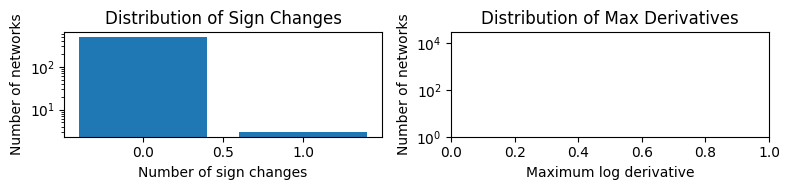

Number of sign changes per network: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [28]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

# List to store number of sign changes for each network
num_sign_changes = []

species_names = data_logger.get_network_by_index(0)['network_params']['species_names']
#l0_list = np.logspace(-3, 3, 50)

# adjacency_matrix = data_logger.get_network_by_index(0)['adjacency_matrix']
# input_substrates_list = data_logger.get_network_by_index(0)['input_substrates_list']
# NR = data_logger.get_network_by_index(0)['NR']
# NS = data_logger.get_network_by_index(0)['NS']
# #target_node = 'S'+str(NS-1)
# target_nodes = 'C'
# G = get_digraph_from_adjacency_matrix(adjacency_matrix, input_substrates_list, NR, NS)
# print("Number of paths from R0 to " + target_node + ": " + str(len(count_simple_paths(G, 'R0', target_node))))
target_node = 'A'

max_deriv_list = []
# Loop over networks
for network_index in range(len(data_logger.network_data)):
    try:
        interaction_matrix = data_logger.get_network_by_index(network_index)['interaction_matrix']
        
        rates = data_logger.get_network_by_index(network_index)['network_params']['reactions']
        target_node_idx = species_names.index(target_node)

        #C_full_list = data_logger.get_network_by_index(network_index)['C_full_list']

        C_full_list = [data_logger.get_network_by_index(network_index)['C_full_list'][i][target_node_idx] for i in range(len(data_logger.get_network_by_index(network_index)['C_full_list']))]
        l0_list = [data_logger.get_network_by_index(network_index)['l0_list'][i][0] for i in range(len(data_logger.get_network_by_index(network_index)['l0_list']))]

        # Get d_log_C values and find sign changes
        d_log_C_d_log_l0_list = convert_to_log(data_logger, network_index)
        d_vals = [d_log_C_d_log_l0_list[i][target_node_idx][0] for i in range(len(C_full_list))]
        #d_vals = [d_log_C_d_log_l0_list[i] for i in range(len(C_full_list))]

        # d_C_d_l0_list = data_logger.get_network_by_index(network_index)['dC_dl_list']
        # d_vals = d_C_d_l0_list

        # Find indices where sign changes occur
        sign_change_indices = []
        for i in range(len(d_vals)-1):
            if d_vals[i] * d_vals[i+1] < 0:  # Sign change occurs
                sign_change_indices.append(i)
        
        C_vals = C_full_list
        l0_x = [np.log10(l0) for l0 in l0_list]
        #l0_x = [l0 for l0 in l0_list]
        d_vals_fd = calculate_finite_differences(C_vals, l0_x, log_y=False, log_x=True)

        max_log_deriv = np.max(np.abs(d_vals * np.array(l0_list)))
        
        
        if check_list_consistency(d_vals_fd, d_vals, threshold=0.2, pad = 4):
            num_sign_changes.append(len(sign_change_indices))
            max_deriv_list.append(max_log_deriv)
        else:
            print(d_vals_fd)
            print(d_vals)
            print(f"Network {network_index} has inconsistent derivatives")

    except Exception as e:
        print(f"Error processing network {network_index}: {e}")

print(np.mean(max_deriv_list))
print(np.std(max_deriv_list))
# Find index of network with maximum number of sign changes
max_sign_changes = max(num_sign_changes)
max_sign_changes_indices = [i for i, x in enumerate(num_sign_changes) if x == max_sign_changes]
print(f"Networks {max_sign_changes_indices} have the most sign changes with {max_sign_changes} changes")

# Create histograms of sign changes and max derivatives
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 2))

# Plot histogram of sign changes
ax1.hist(num_sign_changes, bins=range(min(num_sign_changes), max(num_sign_changes) + 2, 1),
         align='left', rwidth=0.8)
ax1.set_xlabel('Number of sign changes')
ax1.set_ylabel('Number of networks')
ax1.set_title('Distribution of Sign Changes')
ax1.set_yscale('log')

# Plot histogram of max derivatives
ax2.hist(max_deriv_list, bins=20, rwidth=0.8)
ax2.set_xlabel('Maximum log derivative')
ax2.set_ylabel('Number of networks')
ax2.set_title('Distribution of Max Derivatives')
ax2.set_yscale('log')
ax2.set_xlim(0, 1)
ax2.set_ylim(1, 30000)

plt.tight_layout()
plt.show()

print("Number of sign changes per network:", num_sign_changes)

#fig = visualize_dag_signaling_network(adjacency_matrix, input_substrates, NR, NS)
print(adjacency_matrix)

In [27]:
l0_list = [data_logger.get_network_by_index(network_index)['l0_list'][i][1] for i in range(len(data_logger.get_network_by_index(network_index)['l0_list']))]
print(l0_list)

[np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float64(0.00673907062453423), np.float6

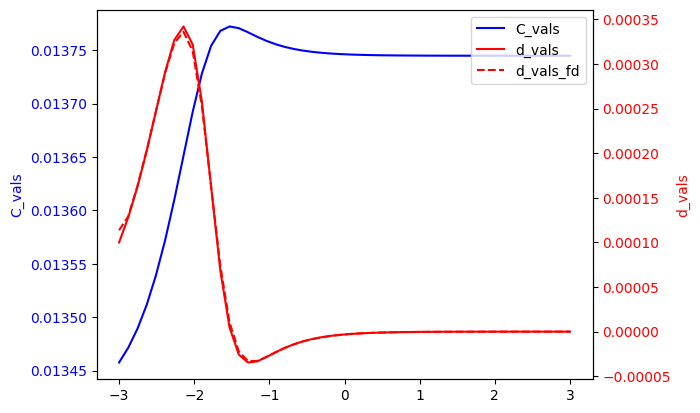

In [29]:
network_index = 264
#target_node_idx = 3
target_node = 'A'

interaction_matrix = data_logger.get_network_by_index(network_index)['interaction_matrix']
        
rates = data_logger.get_network_by_index(network_index)['network_params']['reactions']
target_node_idx = species_names.index(target_node)

# C_full_list = data_logger.get_network_by_index(network_index)['C_full_list']

# #C_full_list = [data_logger.get_network_by_index(network_index)['C_full_list'][i][target_node_idx] for i in range(len(data_logger.get_network_by_index(network_index)['C_full_list']))]
# #l0_list = data_logger.get_network_by_index(network_index)['l0_list']

# # Get d_log_C values and find sign changes
# # d_log_C_d_log_l0_list = convert_to_log(data_logger, network_index)
# # d_vals = [d_log_C_d_log_l0_list[i][target_node_idx][0] for i in range(len(C_full_list))]

# #d_vals = [data_logger.get_network_by_index(network_index)['dC_dl_list'][i][target_node_idx][0] for i in range(len(C_full_list))]

# d_C_d_l0_list = data_logger.get_network_by_index(network_index)['dC_dl_list']
# d_vals = d_C_d_l0_list

C_full_list = [data_logger.get_network_by_index(network_index)['C_full_list'][i][target_node_idx] for i in range(len(data_logger.get_network_by_index(network_index)['C_full_list']))]
d_log_C_d_log_l0_list = convert_to_log(data_logger, network_index, log_y=False, log_x=True)
d_vals = [d_log_C_d_log_l0_list[i][target_node_idx][0] for i in range(len(C_full_list))]

# Find indices where sign changes occur
sign_change_indices = []
for i in range(len(d_vals)-1):
    if d_vals[i] * d_vals[i+1] < 0:  # Sign change occurs
        sign_change_indices.append(i)

C_vals = C_full_list
l0_x = [np.log10(l0) for l0 in l0_list]
#l0_x = [l0 for l0 in l0_list]
d_vals_fd = calculate_finite_differences(C_vals, l0_list, log_y=False, log_x=True)

max_log_deriv = np.max(np.abs(d_vals * np.array(l0_list)))


if check_list_consistency(d_vals_fd, d_vals, threshold=0.2, pad = 4):
    num_sign_changes.append(len(sign_change_indices))
    max_deriv_list.append(max_log_deriv)
else:
    print(d_vals_fd)
    print(d_vals)
    print(f"Network {network_index} has inconsistent derivatives")

# Create figure with two y-axes
fig, ax1 = plt.subplots()

# Plot C_vals on first y-axis
ax1.plot(l0_x, np.array(C_vals), color='blue', label='C_vals')
ax1.set_ylabel('C_vals', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create second y-axis and plot d_vals
ax2 = ax1.twinx()
ax2.plot(l0_x, np.array(d_vals), color='red', label='d_vals')
ax2.plot(l0_x, np.array(d_vals_fd), color='red', linestyle='--', label='d_vals_fd')
ax2.set_ylabel('d_vals', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

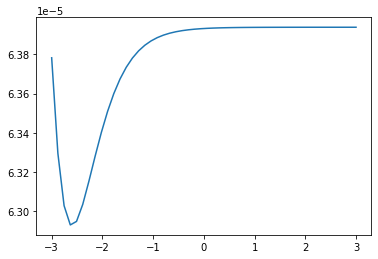

In [10]:
network_index = 66
C_full_list = data_logger.get_network_by_index(network_index)['C_full_list']

plt.plot(l0_x, C_full_list)

In [13]:
import sys

# Print memory usage for each network in data_logger
total_size = sys.getsizeof(data_logger)
for i, network_data in enumerate(data_logger.network_data):
    print(f"\nNetwork {i} memory usage:")
    network_size = 0
    for key, value in network_data.items():
        size = sys.getsizeof(value)
        if isinstance(value, (list, np.ndarray)):
            if isinstance(value, list):
                size += sum(sys.getsizeof(item) for item in value)
            else:
                size += value.nbytes
        network_size += size
        print(f"  {key}: {size:,} bytes")
    total_size += network_size
    print(f"Network {i} total: {network_size:,} bytes")

print(f"\nTotal data_logger size: {total_size:,} bytes")



Network 0 memory usage:
  network_params: 640 bytes
  interaction_matrix: 328 bytes
  cycles: 56 bytes
  n_cycles: 28 bytes
  sign_conditions: 4,408 bytes
  n_sign_conditions: 28 bytes
  C_full_list: 11,608 bytes
  l0_list: 9,688 bytes
  iteration: 24 bytes
  seed: 28 bytes
  dC_dl_list: 29,848 bytes
  E_range: 24 bytes
  B_range: 24 bytes
  F_range: 24 bytes
  C0: 28 bytes
  beta: 28 bytes
  sample_count: 28 bytes
  convergence_reached: 28 bytes
Network 0 total: 56,868 bytes

Network 1 memory usage:
  network_params: 640 bytes
  interaction_matrix: 328 bytes
  cycles: 56 bytes
  n_cycles: 28 bytes
  sign_conditions: 4,408 bytes
  n_sign_conditions: 28 bytes
  C_full_list: 11,608 bytes
  l0_list: 9,688 bytes
  iteration: 28 bytes
  seed: 28 bytes
  dC_dl_list: 29,848 bytes
  E_range: 24 bytes
  B_range: 24 bytes
  F_range: 24 bytes
  C0: 28 bytes
  beta: 28 bytes
  sample_count: 28 bytes
  convergence_reached: 28 bytes
Network 1 total: 56,872 bytes

Network 2 memory usage:
  network_p

In [9]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

# List to store number of sign changes for each network
num_sign_changes = []

# Loop over networks
for network_index in range(len(data_logger.network_data)):
    interaction_matrix = data_logger.get_network_by_index(network_index)['interaction_matrix']
    sign_conditions = data_logger.get_network_by_index(network_index)['sign_conditions']
    rates = data_logger.get_network_by_index(network_index)['network_params']['reactions']
    target_node_idx = species_names.index(target_node)

    C_full_list = data_logger.get_network_by_index(network_index)['C_full_list']
    l0_list = data_logger.get_network_by_index(network_index)['l0_list']
    

    # Get d_log_C values and find sign changes
    d_log_C_d_log_l0_list = convert_to_log(data_logger, network_index)
    d_vals = [d_log_C_d_log_l0_list[i][target_node_idx][0] for i in range(len(C_full_list))]

    # Find indices where sign changes occur
    sign_change_indices = []
    for i in range(len(d_vals)-1):
        if d_vals[i] * d_vals[i+1] < 0:  # Sign change occurs
            sign_change_indices.append(i)
    
    C_vals = [C_full[target_node_idx] for C_full in C_full_list]
    l0_x = [np.log10(l0[0]) for l0 in l0_list]
    d_vals_fd = calculate_finite_differences(C_vals, l0_x, log_y=True, log_x=False)
    
    if check_list_consistency(d_vals_fd, d_vals, threshold=0.2, pad = 4):
        num_sign_changes.append(len(sign_change_indices))
    else:
        print(d_vals_fd)
        print(d_vals)
        print(f"Network {network_index} has inconsistent derivatives")


# Find index of network with maximum number of sign changes
max_sign_changes = max(num_sign_changes)
max_sign_changes_indices = [i for i, x in enumerate(num_sign_changes) if x == max_sign_changes]
print(f"Networks {max_sign_changes_indices} have the most sign changes with {max_sign_changes} changes")

# Create histogram of number of sign changes
plt.figure(figsize=(4, 2))
plt.hist(num_sign_changes, bins=range(min(num_sign_changes), max(num_sign_changes) + 2, 1), 
         align='left', rwidth=0.8)
plt.xlabel('Number of sign changes')
plt.ylabel('Number of networks')
plt.title('Distribution of Sign Changes Across Networks')
plt.yscale('log')
#plt.grid(True, alpha=0.3)
plt.show()

print("Number of sign changes per network:", num_sign_changes)

KeyError: 'sign_conditions'

4
True


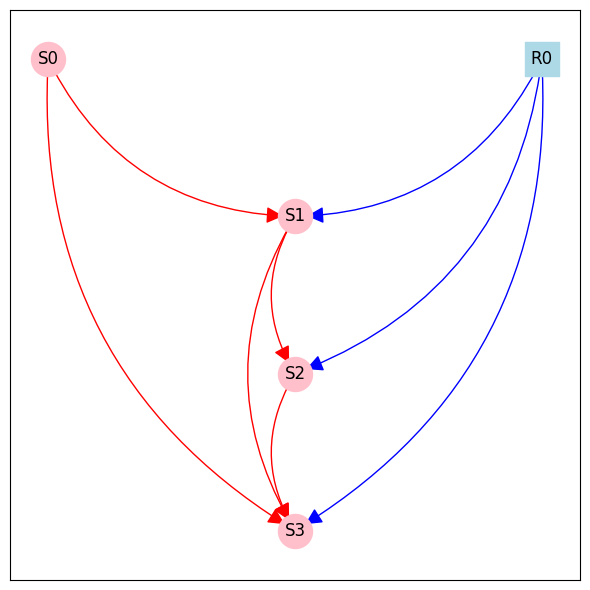

In [6]:
G = get_digraph_from_adjacency_matrix(adjacency_matrix, input_substrates, NR, NS)
print(len(count_simple_paths(G, 'R0', target_node)))
fig = visualize_dag_signaling_network(adjacency_matrix, input_substrates, NR, NS)


In [5]:
# Find index of network with maximum number of sign changes
max_sign_changes = max(num_sign_changes)
max_sign_changes_indices = [i for i, x in enumerate(num_sign_changes) if x == max_sign_changes]
print(f"Networks {max_sign_changes_indices} have the most sign changes with {max_sign_changes} changes")

Networks [109, 373, 491, 523, 919] have the most sign changes with 2 changes


[[0. 0. 0. 0.]
 [2. 0. 0. 0.]
 [2. 2. 0. 0.]
 [2. 0. 2. 0.]]
[[[-1.0]], [[-1.0]], [[-1.0]], [[-1.0]], [[-1.0]], [[-1.0]], [[-1.0]], [[-1.0]], [[-1.0]], [[-1.0]], [[-1.0]], [[-1.0]], [[-1.0]], [[-1.0]], [[-1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]], [[1.0]]]
[(1, 0, np.float64(0.0025664171547221167)), (0, 1, np.float64(3.4325260730752754)), (3, 2, np.float64(0.0801489402585204)), (2, 3, np.float64(0.7403794829200723)), (5, 4, np.float64(0.02182868985112755)), (4, 5, np.float64(6.319694791981051e-05)), (8, 7, np.float64(0.00013614489643355848)), (7, 8, np.float64(0.06793849156387323)), (12, 11, np.float64(4.587891082318155)), (11, 12, 

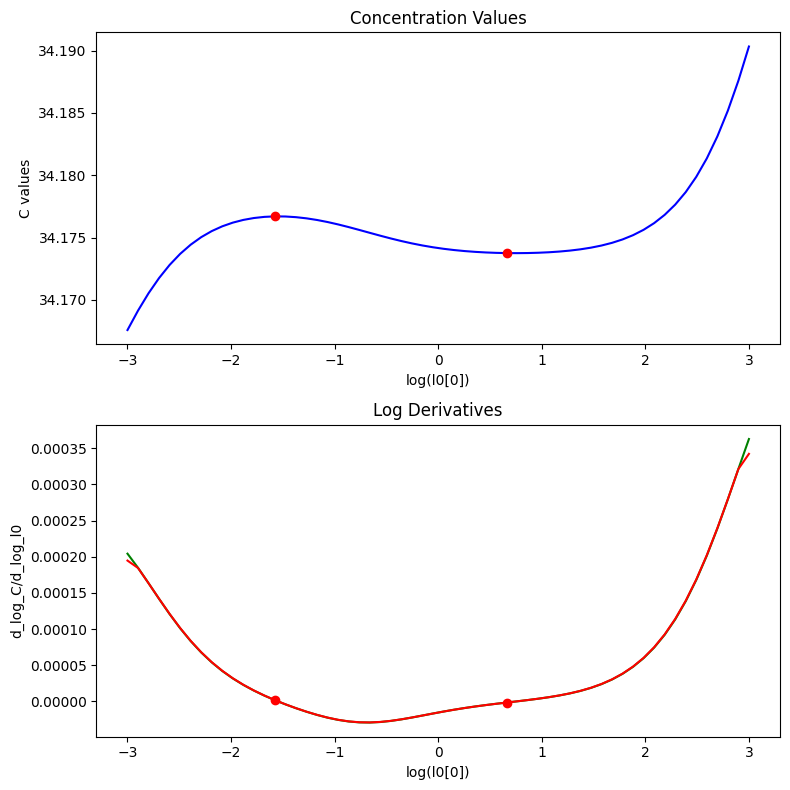

In [10]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

network_index = 919

interaction_matrix = data_logger.get_network_by_index(network_index)['interaction_matrix']
sign_conditions = data_logger.get_network_by_index(network_index)['sign_conditions']
rates = data_logger.get_network_by_index(network_index)['network_params']['reactions']
print(interaction_matrix)
print(sign_conditions)
print(rates)
target_node_idx = species_names.index(target_node)

C_full_list = data_logger.get_network_by_index(network_index)['C_full_list']
l0_list = data_logger.get_network_by_index(network_index)['l0_list']

# Extract coordinates and values and transform to log space
l0_x = [np.log10(l0[0]) for l0 in l0_list]
C_vals = [C_full[target_node_idx] for C_full in C_full_list]


# Get d_log_C values and find sign changes
d_log_C_d_log_l0_list = convert_to_log(data_logger, network_index)
d_vals = [d_log_C_d_log_l0_list[i][target_node_idx][0] for i in range(len(C_full_list))]
d_vals_fd = calculate_finite_differences(np.log10(C_vals), l0_x, log_y=False, log_x=False)
print(check_list_consistency(np.array(d_vals), d_vals_fd, threshold = 0.2, pad = 5))


# Find indices where sign changes occur
sign_change_indices = []
for i in range(len(d_vals)-1):
    if d_vals[i] * d_vals[i+1] < 0:  # Sign change occurs
        sign_change_indices.append(i)

print("Sign changes occur at indices:", sign_change_indices)
print("Corresponding l0 values:", [l0_list[i][0] for i in sign_change_indices])

# Create visualization with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

# Plot C_vals in top subplot
ax1.plot(l0_x, C_vals, c='blue', label='Data points')

# Highlight sign change points in top subplot
for idx in sign_change_indices:
    ax1.plot(l0_x[idx], C_vals[idx], 'ro')

ax1.set_xlabel('log(l0[0])')
ax1.set_ylabel('C values')
ax1.set_title('Concentration Values')

# Plot d_vals in bottom subplot
ax2.plot(l0_x, np.array(d_vals), c='green', label='Derivatives')
ax2.plot(l0_x, d_vals_fd, c='red', label='Finite difference')
# Highlight sign change points in bottom subplot
for idx in sign_change_indices:
    ax2.plot(l0_x[idx], d_vals[idx], 'ro')

ax2.set_xlabel('log(l0[0])')
ax2.set_ylabel('d_log_C/d_log_l0')
ax2.set_title('Log Derivatives')

plt.tight_layout()
plt.show()

In [ ]:
5000 * 1.43 * 60 /(20*3600)

5.958333333333333

In [ ]:
# Print number of samples used for each network
sample_counts = [network['sample_count'] for network in data_logger.network_data]
print("Number of samples used for each network:")
print(sample_counts)

l0_list = [network['l0_list'] for network in data_logger.network_data]
print("Number of l0 values used for each network:")
print(l0_list)

sign_conditions = [network['sign_conditions'] for network in data_logger.network_data]
print("Number of sign conditions used for each network:")
print(sign_conditions)

Number of samples used for each network:
[100, 100, 100, 100, 100, 100, 100, 94, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100]
Number of l0 values used for each network:
[[array([0.01, 0.01, 1.  ]), array([0.01      , 0.02782559, 1.        ]), array([0.01      , 0.07742637, 1.        ]), array([0.01      , 0.21544347, 1.        ]), array([0.01      , 0.59948425, 1.        ]), array([0.01      , 1.66810054, 1.        ]), array([0.01      , 4.64158883, 1.        ]), array([1.00000000e-02, 1.29154967e+01, 1.00000000e+00]), array([1.00000000e-02, 3.59381366e+01, 1.00000000e+00]), array([1.e-02, 1.e+02, 1.e+00]), array([0.02782559, 0.01      , 1.        ]), array([0.02782559, 0.02782559, 1.        ]), array([0.02782559, 0.07742637, 1.        ]), array([0.02782559, 0.21544347, 1.        ]), array([0.02782559, 0.59948425, 1.        ]), array([0.02782559, 1.66810054, 1.        ]), array([0.02782559, 4.64158883, 1.        ]), array([ 0.02782559, 12.91549665,  1.        ]), array([

In [ ]:
data_logger.network_data[0]['r_n']['rates']

KeyError: 'r_n'

In [ ]:
def get_sign_condition_ids(sign_conditions):
    # Create a dictionary to store unique sign conditions and their IDs
    unique_sign_conditions = {}
    sign_condition_ids = []

    # Assign IDs to each sign condition
    for sign_condition in sign_conditions:
        # Convert sign condition to tuple of tuples so it can be used as dict key
        # Each inner list needs to be converted to tuple to be hashable
        sign_condition_tuple = tuple(tuple(x) if isinstance(x, list) else x for x in sign_condition)
        
        # If we haven't seen this sign condition before, assign it a new ID
        if sign_condition_tuple not in unique_sign_conditions:
            unique_sign_conditions[sign_condition_tuple] = len(unique_sign_conditions)
        
        # Add the ID to our list
        sign_condition_ids.append(unique_sign_conditions[sign_condition_tuple])

    return sign_condition_ids



# Get sign conditions and IDs
sign_conditions = data_logger.get_network_by_index(0)['sign_conditions']
sign_condition_ids = get_sign_condition_ids(sign_conditions)

print(f"Original sign condition: {sign_conditions[0]}")
print(f"Assigned ID: {sign_condition_ids[0]}")
print(f"Total unique sign conditions: {len(set(sign_condition_ids))}")

print(sign_condition_ids)


Original sign condition: [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]]
Assigned ID: 0
Total unique sign conditions: 1
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

[[ 0.  0. 10.]
 [ 0.  0.  0.]
 [ 4.  0.  0.]]
[[[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]], [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]], [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]], [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]], [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]], [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]], [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]], [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]], [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]], [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]], [[-1.0, 0.0], [1.0, 0.0], [0.0, 0.0], [-1.0, 0.0]], [[-1.0, 0.0], [1.0, 0.0], [0.0, 0.0], [1.0, 0.0]], [[0.0, 0.0], [1.0, 0.0], [0.0, 0.0], [-1.0, 0.0]], [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]], [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]], [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]], [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]], [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]], [[0.0, 0.0], [0.0, 0.0], [0.0, 0.0], [0.0, 0.0]],

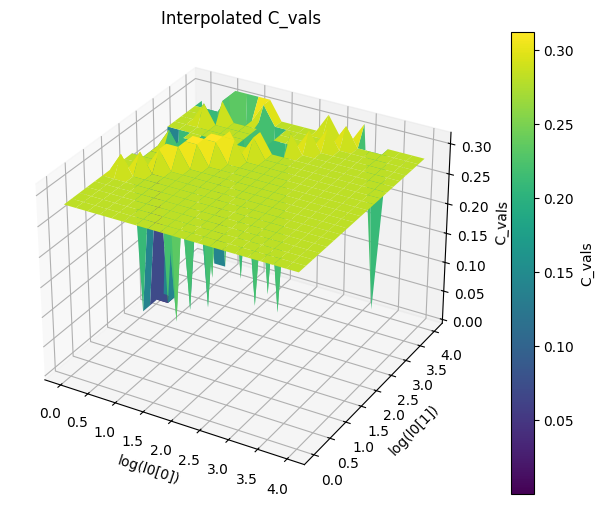

In [ ]:
from scipy.interpolate import griddata
import numpy as np
import matplotlib.pyplot as plt

network_index = 1

interaction_matrix = data_logger.get_network_by_index(network_index)['interaction_matrix']
sign_conditions = data_logger.get_network_by_index(network_index)['sign_conditions']
rates = data_logger.get_network_by_index(network_index)['network_params']['reactions']
print(interaction_matrix)
print(sign_conditions)
print(rates)

C_full_list = data_logger.get_network_by_index(network_index)['C_full_list']
l0_list = data_logger.get_network_by_index(network_index)['l0_list']

# Extract coordinates and values and transform to log space
l0_x = [np.log10(l0[0]) for l0 in l0_list]
l0_y = [np.log10(l0[1]) for l0 in l0_list]
C_vals = [C_full[8] for C_full in C_full_list]

# Create grid of points in log space
grid_x, grid_y = np.meshgrid(
    np.linspace(min(l0_x), max(l0_x), 20),
    np.linspace(min(l0_y), max(l0_y), 20)
)

# Interpolate values in log space
points = np.column_stack((l0_x, l0_y))
C_interpolated = griddata(points, C_vals, (grid_x, grid_y), method='linear')
print(np.max(C_vals)-np.min(C_vals))

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(grid_x, grid_y, C_interpolated, cmap='viridis')
fig.colorbar(surf, label='C_vals')
ax.set_xlabel('log(l0[0])')
ax.set_ylabel('log(l0[1])')
ax.set_zlabel('C_vals')
ax.set_title('Interpolated C_vals')
plt.show()





[0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 2, 1, 0, 0, 0, 0, 0, 2, 1, 3, 0, 0, 0, 0, 0, 0, 0, 4, 4, 4, 2, 1, 4, 0, 1, 0, 1, 4, 4, 4, 4, 4, 0, 2, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 2, 1, 1, 4, 4, 4, 4, 4, 0, 1, 0, 5, 5, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 0, 4, 4]


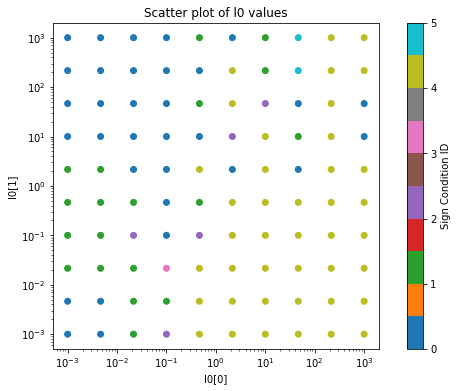

In [ ]:
import matplotlib.pyplot as plt

network_index = 3

print
l0_list = data_logger.get_network_by_index(network_index)['l0_list']
l0_x = [l0[0] for l0 in l0_list]
l0_y = [l0[1] for l0 in l0_list]

sign_conditions = data_logger.get_network_by_index(network_index)['sign_conditions']
sign_condition_ids = get_sign_condition_ids(sign_conditions)


print(sign_condition_ids)
# Plot the l0 values
plt.figure(figsize=(10,6))
scatter = plt.scatter(l0_x, l0_y, c=sign_condition_ids, cmap='tab10')
plt.xlabel('l0[0]')
plt.ylabel('l0[1]') 
plt.xscale('log')
plt.yscale('log')

plt.title('Scatter plot of l0 values')
plt.gca().set_aspect('equal')
plt.colorbar(scatter, label='Sign Condition ID')
#plt.grid(True)
plt.show()

[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 2, 0, 1, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 3, 0, 0, 1, 2, 0, 0, 1, 4, 0, 1, 0, 5, 0, 0, 0, 1, 0, 0, 3, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 6, 0, 0, 1, 1, 0, 0, 1, 7, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 2, 2, 0, 0, 6, 0, 0, 1, 0, 1, 0, 0, 0, 0, 2, 1, 0, 1, 0, 0, 0, 0, 6, 1, 2, 0, 0, 6, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 6, 0, 1, 0, 0, 0, 1, 3, 0, 1, 0, 0, 1, 2, 0, 1, 0, 3, 0, 0, 2, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 6, 0, 1, 1, 0, 0, 0, 0, 1, 7, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 3, 1, 0, 0, 0, 0, 0, 0, 3, 0, 1, 0, 0, 0, 0, 1, 0, 0, 3, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 2, 1, 0, 2, 0, 0, 0, 1, 4, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 6, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 2, 1, 0]


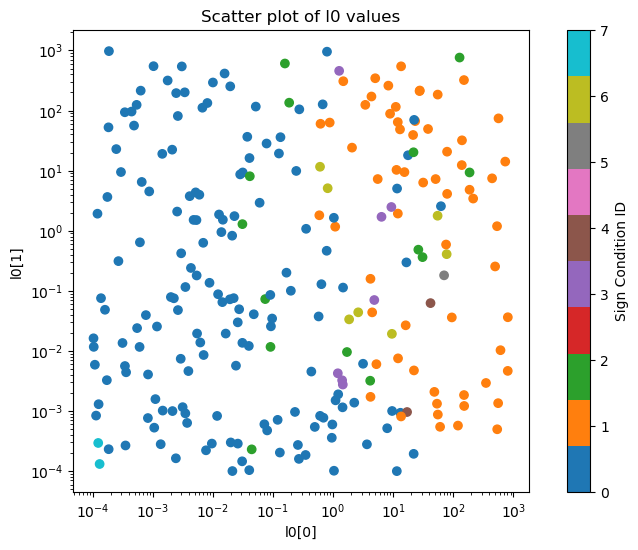

In [ ]:
import matplotlib.pyplot as plt

network_index = 0

print
l0_list = data_logger.get_network_by_index(network_index)['l0_list']
l0_x = [l0[0] for l0 in l0_list]
l0_y = [l0[1] for l0 in l0_list]

sign_conditions = data_logger.get_network_by_index(network_index)['sign_conditions']
sign_condition_ids = get_sign_condition_ids(sign_conditions)


print(sign_condition_ids)
# Plot the l0 values
plt.figure(figsize=(10,6))
scatter = plt.scatter(l0_x, l0_y, c=sign_condition_ids, cmap='tab10')
plt.xlabel('l0[0]')
plt.ylabel('l0[1]') 
plt.xscale('log')
plt.yscale('log')

plt.title('Scatter plot of l0 values')
plt.gca().set_aspect('equal')
plt.colorbar(scatter, label='Sign Condition ID')
#plt.grid(True)
plt.show()

In [ ]:
M_values

array([2, 0, 6, 0, 0, 0, 4, 4, 4, 4, 2, 4, 6, 4, 0, 2, 0, 0, 2, 0, 2, 0,
       4, 0, 2, 0, 6, 2, 4, 0, 2, 2, 0, 6, 4, 6, 2, 2, 2, 2, 4, 2, 2, 0,
       4, 0, 2, 2, 6, 2])

2


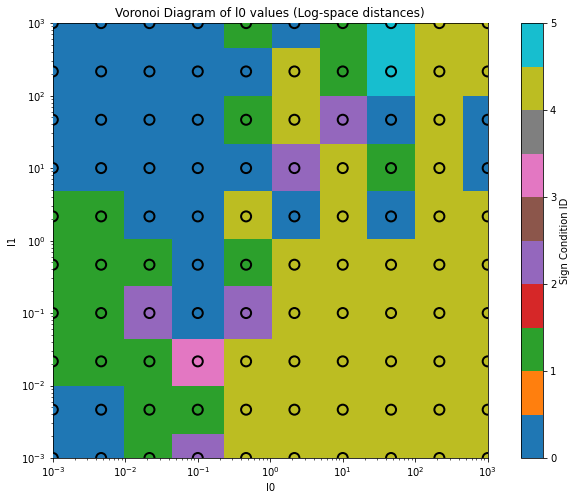

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])

grid_size = 200

network_index = 3
print(M_values[network_index])

l0_list = data_logger.get_network_by_index(network_index)['l0_list']
l0_x = [l0[0] for l0 in l0_list]
l0_y = [l0[1] for l0 in l0_list]

sign_conditions = data_logger.get_network_by_index(network_index)['sign_conditions']
sign_condition_ids = get_sign_condition_ids(sign_conditions)

# Create a much finer grid using log spacing
x_min, x_max = min(l0_x), max(l0_x)
y_min, y_max = min(l0_y), max(l0_y)

# Add padding
padding_x = (x_max - x_min) * 0.2
padding_y = (y_max - y_min) * 0.2

# Create grid bounds in log space
x_start = max(x_min - padding_x, 1e-10)
x_end = x_max + padding_x
y_start = max(y_min - padding_y, 1e-10)
y_end = y_max + padding_y

# Create a very fine grid using log spacing
x_grid = np.logspace(np.log10(x_start), np.log10(x_end), grid_size)
y_grid = np.logspace(np.log10(y_start), np.log10(y_end), grid_size)

# Filter out any non-finite values
x_grid = x_grid[np.isfinite(x_grid)]
y_grid = y_grid[np.isfinite(y_grid)]

X, Y = np.meshgrid(x_grid, y_grid)

# Calculate regions for each grid point using log-space distances
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        # Find the closest original point using log-space distances
        log_distances = np.sqrt((np.log10(l0_x) - np.log10(X[i, j]))**2 + 
                               (np.log10(l0_y) - np.log10(Y[i, j]))**2)
        closest_idx = np.argmin(log_distances)
        Z[i, j] = sign_condition_ids[closest_idx]

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the colored regions
mesh = ax.pcolormesh(X, Y, Z, cmap='tab10', shading='auto')

# Plot the original points
scatter = ax.scatter(l0_x, l0_y, c=sign_condition_ids, cmap='tab10', s=100, 
                    edgecolors='black', linewidth=2, zorder=5)

# Set log scales
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(min(l0_x), max(l0_x))
ax.set_ylim(min(l0_y), max(l0_y))

ax.set_xlabel('l0')
ax.set_ylabel('l1')
ax.set_title('Voronoi Diagram of l0 values (Log-space distances)')
ax.set_aspect('equal')

# Add colorbar
plt.colorbar(mesh, ax=ax, label='Sign Condition ID')

plt.show()

4


/var/folders/vz/mzz963fn35g6stbyn1w_x0jc0000gn/T/ipykernel_43134/4003078849.py:77: RuntimeWarning: overflow encountered in power
  v1_linear = 10**v1


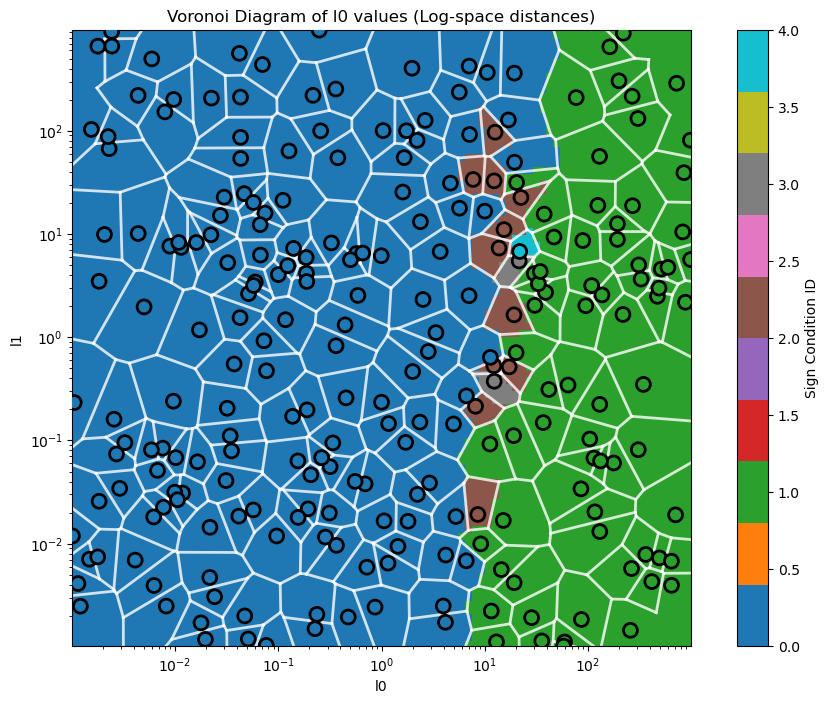

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi, voronoi_plot_2d

network_index = 7

M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])

grid_size = 200

print(M_values[network_index])

l0_list = data_logger.get_network_by_index(network_index)['l0_list']
l0_x = [l0[0] for l0 in l0_list]
l0_y = [l0[1] for l0 in l0_list]

sign_conditions = data_logger.get_network_by_index(network_index)['sign_conditions']
sign_condition_ids = get_sign_condition_ids(sign_conditions)

# Create points array
points = np.column_stack((l0_x, l0_y))

# Transform points to log space for Voronoi computation
log_points = np.column_stack((np.log10(l0_x), np.log10(l0_y)))
vor = Voronoi(log_points)

# Create a much finer grid using log spacing
x_min, x_max = min(l0_x), max(l0_x)
y_min, y_max = min(l0_y), max(l0_y)

# Add padding
padding_x = (x_max - x_min) * 0.2
padding_y = (y_max - y_min) * 0.2

# Create grid bounds in log space
x_start = max(x_min - padding_x, 1e-10)
x_end = x_max + padding_x
y_start = max(y_min - padding_y, 1e-10)
y_end = y_max + padding_y

# Create a very fine grid using log spacing
x_grid = np.logspace(np.log10(x_start), np.log10(x_end), grid_size)
y_grid = np.logspace(np.log10(y_start), np.log10(y_end), grid_size)

# Filter out any non-finite values
x_grid = x_grid[np.isfinite(x_grid)]
y_grid = y_grid[np.isfinite(y_grid)]

X, Y = np.meshgrid(x_grid, y_grid)

# Calculate regions for each grid point using log-space distances
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        # Find the closest original point using log-space distances
        log_distances = np.sqrt((np.log10(l0_x) - np.log10(X[i, j]))**2 + 
                               (np.log10(l0_y) - np.log10(Y[i, j]))**2)
        closest_idx = np.argmin(log_distances)
        Z[i, j] = sign_condition_ids[closest_idx]

# Create the plot
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the colored regions
mesh = ax.pcolormesh(X, Y, Z, cmap='tab10', shading='auto')

# Plot the original points
scatter = ax.scatter(l0_x, l0_y, c=sign_condition_ids, cmap='tab10', s=100, 
                    edgecolors='black', linewidth=2, zorder=5)

# Add Voronoi region outlines (transformed from log space)
for ridge in vor.ridge_vertices:
    if ridge[0] != -1 and ridge[1] != -1:  # Skip ridges extending to infinity
        v1 = vor.vertices[ridge[0]]
        v2 = vor.vertices[ridge[1]]
        # Transform back from log space to linear space
        v1_linear = 10**v1
        v2_linear = 10**v2
        ax.plot([v1_linear[0], v2_linear[0]], [v1_linear[1], v2_linear[1]], 
                'white', linewidth=2, alpha=0.8)

# Set log scales
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(min(l0_x), max(l0_x))
ax.set_ylim(min(l0_y), max(l0_y))

ax.set_xlabel('l0')
ax.set_ylabel('l1')
ax.set_title('Voronoi Diagram of l0 values (Log-space distances)')
ax.set_aspect('equal')

# Add colorbar
plt.colorbar(mesh, ax=ax, label='Sign Condition ID')

plt.show()

In [ ]:
import numpy as np
from scipy.spatial import Voronoi
from collections import defaultdict
import networkx as nx

def count_connected_components_voronoi(points, labels, log_transform=True):
    """
    Count connected components in Voronoi diagram using graph approach.
    
    Args:
        points: array of shape (n, 2) with xy coordinates
        labels: array of length n with labels for each point
    
    Returns:
        dict: {label: number_of_connected_components}
    """
    # Create Voronoi diagram

    # Transform points to log space for Voronoi computation
    if log_transform:
        points = np.column_stack((np.log10(points[:,0]), np.log10(points[:,1])))
    vor = Voronoi(points)

    
    # Build adjacency graph
    G = nx.Graph()
    
    # Add nodes for each point
    for i, label in enumerate(labels):
        G.add_node(i, label=label)
    
    # Add edges between adjacent Voronoi regions
    for ridge in vor.ridge_points:
        if ridge[0] != -1 and ridge[1] != -1:  # Skip ridges to infinity
            point1, point2 = ridge[0], ridge[1]
            # Only connect points with the same label
            if labels[point1] == labels[point2]:
                G.add_edge(point1, point2)
    
    # Find connected components for each label
    label_components = defaultdict(int)
    
    # Group nodes by label
    nodes_by_label = defaultdict(list)
    for node in G.nodes():
        label = G.nodes[node]['label']
        nodes_by_label[label].append(node)
    
    # Count connected components for each label
    for label, nodes in nodes_by_label.items():
        # Get subgraph for this label
        subgraph = G.subgraph(nodes)
        # Count connected components in subgraph
        num_components = nx.number_connected_components(subgraph)
        label_components[label] = num_components
    
    return dict(label_components)

# Usage example:
points = np.column_stack((l0_x, l0_y))
labels = sign_condition_ids
component_counts = count_connected_components_voronoi(points, labels)
print(component_counts)

{0: 1, 1: 1, 2: 5, 3: 2, 4: 1}


In [ ]:
print(len(data_logger.get_network_by_index(6)['l0_list']))
print(len(data_logger.get_network_by_index(6)['sign_conditions']))

29
29


In [ ]:
sample_counts = [network['additional_data']['sample_count'] for network in data_logger.network_data]
print(sample_counts)

l0_list = [network['l0_list'] for network in data_logger.network_data]
print("Number of l0 values used for each network:")
print(l0_list)

[46, 38, 21, 21, 23, 53, 27, 39, 23, 30, 57, 30, 21, 32, 26, 41, 96, 160, 86, 110, 51, 24, 48, 47, 22, 22, 50, 78, 44, 79, 30, 29, 103, 39, 25, 48, 64, 21, 47, 37, 40, 35, 51, 32, 54, 30, 62, 66, 21, 48]
Number of l0 values used for each network:
[[array([0.00243698, 0.0001638 ]), array([139.09277743,  12.36085739]), array([0.61117632, 0.00083216]), array([ 0.07864509, 28.25541288]), array([1.22267085, 0.00189854]), array([6.06143893e+01, 5.46780269e-04]), array([0.00966133, 0.0002877 ]), array([2.48375819e-04, 2.28134374e+01]), array([1.20925031e-04, 1.92133630e+00]), array([0.0210463 , 0.82706293]), array([0.02230989, 0.07555754]), array([3.45134610e-04, 9.36054062e+01]), array([0.12020214, 0.00071397]), array([1.32477576e+01, 9.36434182e-04]), array([23.34319751, 66.6696806 ]), array([0.01473827, 1.52431959]), array([127.86368569, 760.58204347]), array([  0.18699197, 134.96198687]), array([0.01181628, 0.00082992]), array([79.38263935,  4.10444204]), array([1.47257436, 0.11336419]), 

In [ ]:
sample_counts = [network['additional_data']['sample_count'] for network in data_logger.network_data]
print("Number of samples used for each network:")
print(sample_counts)

Number of samples used for each network:
[21, 34, 25, 46, 113, 24, 33, 105, 120, 33, 88, 37, 53, 23, 30, 125, 44, 31, 28, 21, 33, 44, 31, 32, 21, 21, 73, 59, 41, 36, 102, 41, 33, 72, 39, 43, 24, 24, 58, 25, 21, 83, 42, 45, 41, 38, 26, 27, 39, 115]


In [ ]:
print(len(data_logger.get_network_by_index(1)['sign_conditions']))

34


Text(0, 0.5, 'Number of sign conditions')

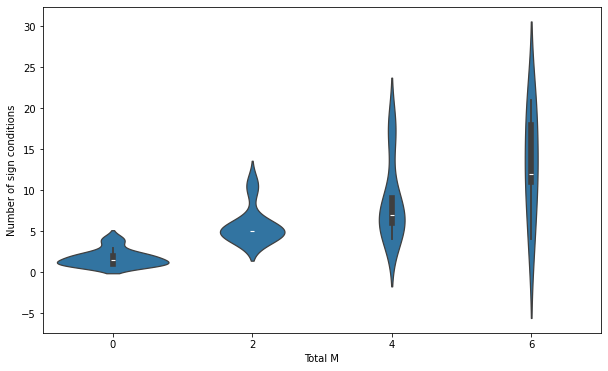

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])
n_sign_conditions = np.array([data_logger.network_data[n]['n_sign_conditions'] for n in range(len(data_logger.network_data))])

plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions)
plt.xlabel('Total M')

plt.ylabel('Number of sign conditions')

Text(0, 0.5, 'Number of sign conditions')

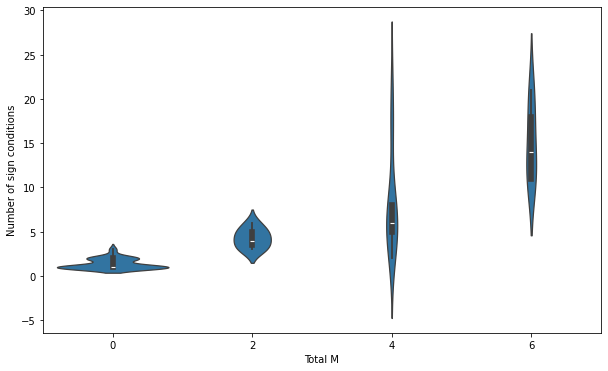

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

M_values = np.array([data_logger.network_data[n]['conservation_changes']['M_0t1'] + data_logger.network_data[n]['conservation_changes']['M_1t0'] + data_logger.network_data[n]['conservation_changes']['M_0b1'] for n in range(len(data_logger.network_data))])
n_sign_conditions = np.array([data_logger.network_data[n]['n_sign_conditions'] for n in range(len(data_logger.network_data))])

plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions)
plt.xlabel('Total M')

plt.ylabel('Number of sign conditions')

Text(0, 0.5, 'Number of sign conditions')

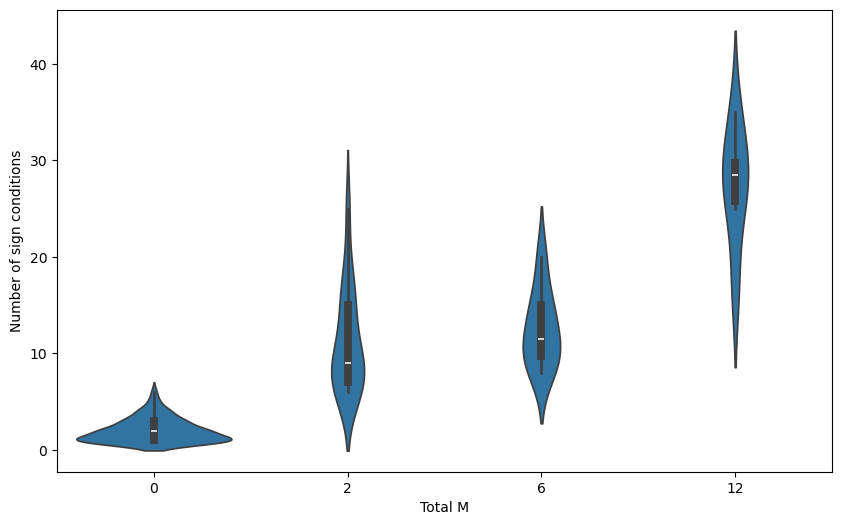

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

n_sign_conditions = np.array([len(s) for s in sign_conditions_list])
M_values = np.array(M_0t1_list) + np.array(M_1t0_list) + np.array(M_0b1_list)


plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions)
plt.xlabel('Total M')

plt.ylabel('Number of sign conditions')

#plt.grid(True, alpha=0.3)

Text(0, 0.5, 'Number of sign conditions')

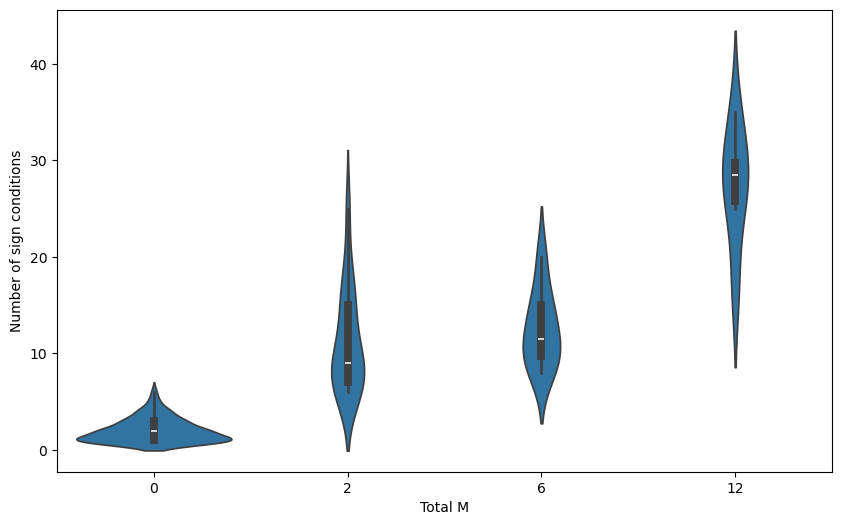

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

n_sign_conditions = np.array([len(s) for s in sign_conditions_list])
M_values = np.array(M_0t1_list) + np.array(M_1t0_list) + np.array(M_0b1_list)


plt.figure(figsize=(10,6))
sns.violinplot(x=M_values, y=n_sign_conditions)
plt.xlabel('Total M')

plt.ylabel('Number of sign conditions')

#plt.grid(True, alpha=0.3)

In [4]:
from CRNs import *
from CRNs.utils import NetworkDataLogger
import numpy as np
import argparse
import time
import copy
import pickle
import ast


#seed = args.param2
seed = 40

### Signaling network 
NR = 1
# NS = 3
# p_f = 0.8
p_r = 0
# Convert string to list of integers
# NS_vec = [int(digit) for digit in args.param1]
# NS_vec.append(1)
NS_vec = [2,1]
NS = sum(NS_vec)
target_node = 'S'+str(NS-1)

E_range = 10.0
B_range = 10.0
F_range = 10.0
C0 = 1
beta = 1
l0_range = (1e-4, 1e4)

# E_range = 5.0
# B_range = 5.0
# F_range = 5.0
# C0 = 1
# beta = 1
# l0_range = (1e-3, 1e3)


n_graph_samples = 200

t_span = (0, 10000)
num_points = 10000
int_method = 'LSODA'
r_tol = 1e-12  
a_tol = 1e-12


if seed is not None:
    np.random.seed(seed)
    random.seed(seed)

#species_names, reaction_strings, L, adjacency_matrix, input_substrates = generate_dag_signaling_network(NR, NS, p_f, p_r, include_reverse=True, include_uncatalyzed=True)
species_names, reaction_strings, L, adjacency_matrix, input_substrates_list = generate_layered_feedforward_signaling_network(NR, NS_vec, p_r, include_reverse=False, include_uncatalyzed=True)

G = get_digraph_from_adjacency_matrix(adjacency_matrix, input_substrates_list, NR, NS)
target_node = 'S'+str(NS-1)
target_node_idx = species_names.index(target_node)

print("Number of paths is", len(count_simple_paths(G, 'R0', target_node)))

r_n = ReactionNetwork.from_reaction_strings(
    reaction_strings=reaction_strings,
    L=L,
    seed=seed,
    species_names=species_names,
    force_reverse=True
)
n_species = r_n.n_species
n_complexes = r_n.n_complexes
n_reactions = int(r_n.n_reactions / 2)
n_lcs = r_n.n_lcs
n_cons = len(L)
r_n_base = r_n

lhs_bool = False

if lhs_bool:
    E_lists = [(-E_range, E_range) for _ in range(n_species)]
    B_lists = [(-B_range, B_range) for _ in range(n_reactions)]
    F_lists = [(-F_range, F_range) for _ in range(n_reactions)]
    l0_lists = [(np.log10(l0_range[0]), np.log10(l0_range[1])) for _ in range(n_cons)]
    ranges = E_lists + B_lists + F_lists + l0_lists
    samples = list(latin_hypercube_sampling(ranges, n_graph_samples, seed))


input_dims = [0]
default_l0 = np.ones(NR+NS)
sc_grad_dims = [[NR+NS-1],[0]]


# Initialize data logger and time profiler
data_logger = NetworkDataLogger()
profiler = TimeProfiler()
profiler.start_total_timer()

sampler = GridSampler(
    input_dims=input_dims,
    default_l0=default_l0,
    sc_grad_dims=sc_grad_dims,
    l0_range=l0_range,
    l0_grid_size=50,
    grid_dim=1,
    timeout_seconds=1,
    profiler=profiler,
    round_decimals=6,
    use_signal_alarms=False,
    use_contour_integration=True
)

for iter in range(n_graph_samples):

    signal.signal(signal.SIGALRM, timeout_handler)
    signal.alarm(2)
    # Time network generation
    profiler.start_timer("network_generation")

    try:
        if r_n_base is None:
            r_n = ReactionNetwork(  
                n_species, 
                n_complexes, n_reactions, n_lcs, 
                L, seed, force_reverse=force_reverse, subset_group_ind=subset_group_ind, 
                #complexes_per_class=complexes_per_class, reactions_per_class=reactions_per_class
            )
        else:
            r_n = r_n_base
        if lhs_bool:
            sample = samples[iter]
            E_list = sample[:n_species]
            B_list = sample[n_species:n_species+n_reactions]
            F_list = sample[n_species+n_reactions:n_species+n_reactions+n_reactions]
            reac_rates = get_rates_from_exponents(r_n, E_list, B_list, F_list, C0, beta)
            r_n.update_rates(reac_rates)

            l0_list = 10**np.array(sample[n_species+n_reactions+n_reactions:])
            sampler.default_l0 = default_l0

        else:
            reac_rates = generate_thermodynamic_rates(r_n, C0, beta, E_range, B_range, F_range)
            r_n.update_rates(reac_rates)

            default_l0 = np.exp(np.random.uniform(np.log(l0_range[0]), np.log(l0_range[1]), n_cons))
            sampler.default_l0 = default_l0

        profiler.end_timer("network_generation")
    except Exception as e:
        profiler.end_timer("network_generation")
        print(f"Error creating reaction network: {e}, skipping...")
        continue
    
    if r_n_base is None or iter == 0:
        # Time conservation group analysis
        profiler.start_timer("conservation_analysis")
        # M_0t1, M_1t0, M_0b1 = count_conservation_group_changes(r_n)
        interaction_matrix = get_interaction_matrix(r_n)
        profiler.end_timer("conservation_analysis")
        
        # Time data storage operations
        profiler.start_timer("data_storage")
        cycles = compute_cycles(r_n)
        profiler.end_timer("data_storage")

        # Time simulator initialization
        profiler.start_timer("simulator_init")
        sim = ReactionNetworkSimulator(r_n)
        profiler.end_timer("simulator_init")
        
        # Time conservation laws solving
        profiler.start_timer("conservation_laws")
        sim.solve_conservation_laws()
        profiler.end_timer("conservation_laws")
        
        # Time symbolic RHS generation
        profiler.start_timer("symbolic_rhs")
        reduced_rhs, remaining_syms, const_syms, rate_syms = sim.get_symbolic_reduced_rhs()
        profiler.end_timer("symbolic_rhs")
        
        # Time derivatives computation
        profiler.start_timer("derivatives")
        # Only compute the derivatives we actually use
        dR_dC, dR_dC_func, dR_dl, dR_dl_func, dR_dk, dR_dk_func, remaining_syms = sim.get_first_order_derivatives()
        # Store the derivative functions that will be reused in adaptive sampling
        precomputed_derivatives = (dR_dC_func, dR_dl_func)

        profiler.end_timer("derivatives")
        
        # Time rates creation
        profiler.start_timer("rates_creation")
        rates = np.array([r_n.reactions[r_idx][2] for r_idx in range(len(r_n.reactions))])
        profiler.end_timer("rates_creation")
        
        # Time flexible RHS creation
        profiler.start_timer("flexible_rhs")
        flexible_reduced_ode_rhs = sim.make_reduced_rhs_with_conservation_flexible()
        profiler.end_timer("flexible_rhs")

    # Use adaptive sampling instead of fixed sampling
    # Note: The adaptive sampler handles its own internal timing with "adaptive_" prefixed timers
    profiler.start_timer("adaptive_sampling")
    sign_conditions, C_full_list, dC_dl_list, l0_list, sample_count, convergence_reached = sampler.sample_sign_conditions(
        sim=sim,
        L=L,
        t_span=t_span,
        num_points=num_points,
        int_method=int_method,
        r_tol=r_tol,
        a_tol=a_tol,
        precomputed_derivatives=precomputed_derivatives
    )
    profiler.end_timer("adaptive_sampling")
    
    # Reset sampler for next network
    sampler.reset()
    
    # Log the network data using the new logger
    profiler.start_timer("data_logging")


    dC_dl_list_sub = [dC_dl[target_node_idx, input_dims[0]] for dC_dl in dC_dl_list]
    C_full_list_sub = [C_full[target_node_idx] for C_full in C_full_list]

    if signal.alarm(0) == 0:
        sig_bool = True
    else:
        sig_bool = False
    print(sig_bool)

    data_logger.log_network(
        r_n=r_n,
        interaction_matrix=interaction_matrix,
        input_substrates_list=input_substrates_list,
        NR=NR,
        NS=NS,
        target_node=target_node,
        cycles=cycles,
        adjacency_matrix=adjacency_matrix,
        C_full_list=C_full_list_sub,
        dC_dl_list=dC_dl_list_sub,
        l0_list=l0_list,
        iteration=iter,
        seed=seed, 
        sig_bool=sig_bool
    )
    profiler.end_timer("data_logging")

    if iter%20 == 0:
        print(f"Iteration {iter} complete")
        
    #signal.alarm(0)

profiler.end_total_timer()

# Print detailed timing information
profiler.print_summary()



Number of paths is 2
False
Iteration 0 complete
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
Iteration 20 complete
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
Iteration 40 complete
False
False
False
False
False
False
False
False
False
False
False
False
False
Error in steady state integration: ODE integration timed out
True
False
False
False
False
False
False
Iteration 60 complete
False
False
False
False
False
False
False
False
False
False
False
False
Error in steady state integration: ODE integration timed out
True
False
False
False
False
False
False
False
Iteration 80 complete
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
Iteration 100 complete
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
False
I

In [5]:
sig_bools = [data_logger.network_data[i]['sig_bool'] for i in range(len(data_logger.network_data))]
print(sig_bools)
for (i, sig_bool) in enumerate(sig_bools):
    if sig_bool:
        print(i)

[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, 